Sample: 100%|██████████| 1200/1200 [1:27:34,  4.38s/it, step size=6.55e-04, acc. prob=0.793]


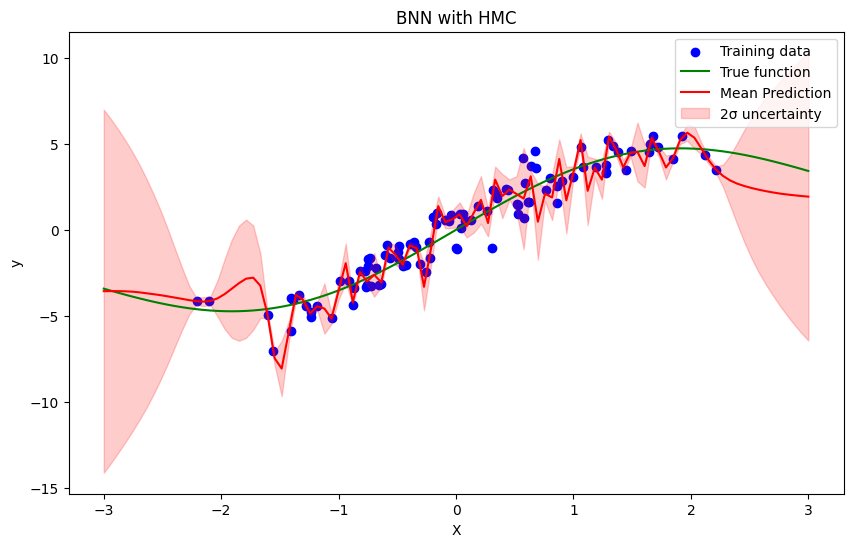

In [1]:
import torch
import torch.nn as nn
import pyro
import pyro.distributions as dist
from pyro.infer import MCMC, NUTS
import matplotlib.pyplot as plt
import numpy as np
import pyro.optim as optim

# MLPの定義 (通常のNNとして定義)
class MLP(nn.Module):
    def __init__(self, input_dim, output_dim, hidden_units, activations):
        super(MLP, self).__init__()
        layers = []
        in_dim = input_dim

        # 指定された hidden_units と activations に基づいて層を構築
        for hidden_dim, activation in zip(hidden_units, activations):
            layers.append(nn.Linear(in_dim, hidden_dim))
            layers.append(self.get_activation(activation))
            in_dim = hidden_dim

        # 最後の出力層
        layers.append(nn.Linear(in_dim, output_dim))
        self.mlp = nn.Sequential(*layers)

    def forward(self, x):
        return self.mlp(x)

    @staticmethod
    def get_activation(activation):
        # 活性化関数の設定
        if activation == "relu":
            return nn.ReLU()
        elif activation == "tanh":
            return nn.Tanh()
        elif activation == "sigmoid":
            return nn.Sigmoid()
        else:
            raise ValueError(f"Unsupported activation function: {activation}")

# 真の関数 (ground truth)
def true_function(x):
    return 3 * np.sin(x) + x

# Pyroのモデル定義
def bayesian_model(X, y, model_settings):
    input_dim = model_settings["input_dim"]
    hidden_units = model_settings["hidden_units"]
    output_dim = model_settings["output_dim"]
    activations = model_settings["activations"]

    # 正規分布から事前分布を仮定
    layer_sizes = [input_dim] + hidden_units + [output_dim]

    # 各層の重み・バイアスを事前分布としてサンプリング
    weights = []
    biases = []
    for i in range(len(layer_sizes) - 1):
        w = pyro.sample(f"weight_{i}", dist.Normal(0, 1).expand([layer_sizes[i+1], layer_sizes[i]]).to_event(2))
        b = pyro.sample(f"bias_{i}", dist.Normal(0, 1).expand([layer_sizes[i+1]]).to_event(1))
        weights.append(w)
        biases.append(b)

    # フォワード計算を実行
    def forward(X):
        out = X
        for i in range(len(weights)):
            out = torch.matmul(out, weights[i].T) + biases[i]
            if i < len(weights) - 1:  # 最後の層以外に活性化関数を適用
                out = MLP.get_activation(activations[i])(out)
        return out

    # 観測値の分布を定義
    with pyro.plate("data", X.shape[0]):
        y_hat = forward(X)
        pyro.sample("obs", dist.Normal(y_hat, 1), obs=y)

# HMCサンプリング
def hmc_inference(model_settings, X_train, y_train, num_samples=1000, warmup_steps=200):
    nuts_kernel = NUTS(bayesian_model)  # NUTS: HMCの拡張版
    mcmc = MCMC(nuts_kernel, num_samples=num_samples, warmup_steps=warmup_steps)
    mcmc.run(X_train, y_train, model_settings)
    return mcmc.get_samples()

# 予測関数 (事後分布サンプルから平均と標準偏差を計算)
def predict_with_hmc(samples, X_test, model_settings):
    weights = [samples[f"weight_{i}"] for i in range(len(model_settings['hidden_units']) + 1)]
    biases = [samples[f"bias_{i}"] for i in range(len(model_settings['hidden_units']) + 1)]

    preds = []
    for w, b in zip(zip(*weights), zip(*biases)):
        def forward(X):
            out = X
            for i in range(len(w)):
                out = torch.matmul(out, w[i].T) + b[i]
                if i < len(w) - 1:
                    out = MLP.get_activation(model_settings['activations'][i])(out)
            return out
        preds.append(forward(X_test))

    preds = torch.stack(preds)
    mean_preds = preds.mean(0)
    std_preds = preds.std(0)
    return mean_preds, std_preds

# モデルのトレーニングと予測
def train_and_predict_with_hmc(model_settings, num_samples=1000, warmup_steps=200):
    torch.manual_seed(42)
    X_train = torch.randn(100, 1)  # 訓練データ
    y_train = true_function(X_train) + torch.randn(100, 1)  # ノイズを加えた出力

    # HMCによるサンプリング
    samples = hmc_inference(model_settings, X_train, y_train, num_samples, warmup_steps)

    # 予測
    X_test = torch.linspace(-3, 3, 100).unsqueeze(1)  # テストデータ
    mean_preds, std_preds = predict_with_hmc(samples, X_test, model_settings)

    return X_train, y_train, X_test, mean_preds, std_preds


# プロット
def plot_results(X_train, y_train, X_test, mean_preds, std_preds, n_sigma=2):
    X_train_np, y_train_np = X_train.numpy(), y_train.numpy()
    X_test_np, mean_preds_np = X_test.numpy(), mean_preds.detach().numpy()
    y_true_np = true_function(X_test_np)
    std_preds_np = std_preds.detach().numpy()

    plt.figure(figsize=(10, 6))
    plt.scatter(X_train_np, y_train_np, label="Training data", color='blue')
    plt.plot(X_test_np, y_true_np, label="True function", color='green')
    plt.plot(X_test_np, mean_preds_np, label="Mean Prediction", color='red')
    plt.fill_between(X_test_np.flatten(), 
                     mean_preds_np.flatten() - n_sigma * std_preds_np.flatten(),
                     mean_preds_np.flatten() + n_sigma * std_preds_np.flatten(),
                     color='red', alpha=0.2, label=f'{n_sigma}σ uncertainty')
    plt.title('BNN with HMC')
    plt.xlabel('X')
    plt.ylabel('y')
    plt.legend()
    plt.show()


if __name__ == "__main__":
    # モデルの設定
    model_settings = {
        "input_dim": 1,
        "output_dim": 1,
        "hidden_units": [128, 128, 128],
        "activations": ["tanh", "tanh", "tanh"]
    }

    # HMCでの予測
    X_train, y_train, X_test, mean_preds, std_preds = train_and_predict_with_hmc(model_settings)

    # 結果の可視化
    plot_results(X_train, y_train, X_test, mean_preds, std_preds, n_sigma=2)


In [ ]:
import torch
import torch.nn as nn
import pyro
import pyro.distributions as dist
from pyro.infer import MCMC, NUTS
import matplotlib.pyplot as plt
import numpy as np
import pyro.optim as optim

# MLPの定義 (通常のNNとして定義)
class MLP(nn.Module):
    def __init__(self, input_dim, output_dim, hidden_units, activations):
        super(MLP, self).__init__()
        layers = []
        in_dim = input_dim

        # 指定された hidden_units と activations に基づいて層を構築
        for hidden_dim, activation in zip(hidden_units, activations):
            layers.append(nn.Linear(in_dim, hidden_dim))
            layers.append(self.get_activation(activation))
            in_dim = hidden_dim

        # 最後の出力層
        layers.append(nn.Linear(in_dim, output_dim))
        self.mlp = nn.Sequential(*layers)

    def forward(self, x):
        return self.mlp(x)

    @staticmethod
    def get_activation(activation):
        # 活性化関数の設定
        if activation == "relu":
            return nn.ReLU()
        elif activation == "tanh":
            return nn.Tanh()
        elif activation == "sigmoid":
            return nn.Sigmoid()
        else:
            raise ValueError(f"Unsupported activation function: {activation}")

# 真の関数 (ground truth)
def true_function(x):
    return 3 * np.sin(x) + x

# Pyroのモデル定義
def bayesian_model(X, y, model_settings):
    input_dim = model_settings["input_dim"]
    hidden_units = model_settings["hidden_units"]
    output_dim = model_settings["output_dim"]
    activations = model_settings["activations"]

    # 正規分布から事前分布を仮定
    layer_sizes = [input_dim] + hidden_units + [output_dim]

    # 各層の重み・バイアスを事前分布としてサンプリング
    weights = []
    biases = []
    for i in range(len(layer_sizes) - 1):
        w = pyro.sample(f"weight_{i}", dist.Normal(0, 1).expand([layer_sizes[i+1], layer_sizes[i]]).to_event(2))
        b = pyro.sample(f"bias_{i}", dist.Normal(0, 1).expand([layer_sizes[i+1]]).to_event(1))
        weights.append(w)
        biases.append(b)

    # フォワード計算を実行
    def forward(X):
        out = X
        for i in range(len(weights)):
            out = torch.matmul(out, weights[i].T) + biases[i]
            if i < len(weights) - 1:  # 最後の層以外に活性化関数を適用
                out = MLP.get_activation(activations[i])(out)
        return out

    # 観測値の分布を定義
    with pyro.plate("data", X.shape[0]):
        y_hat = forward(X)
        pyro.sample("obs", dist.Normal(y_hat, 1), obs=y)

# HMCサンプリング
def hmc_inference(model_settings, X_train, y_train, num_samples=1000, warmup_steps=200):
    nuts_kernel = NUTS(bayesian_model)  # NUTS: HMCの拡張版
    mcmc = MCMC(nuts_kernel, num_samples=num_samples, warmup_steps=warmup_steps)
    mcmc.run(X_train, y_train, model_settings)
    return mcmc.get_samples()

# 予測関数 (事後分布サンプルから平均と標準偏差を計算)
def predict_with_hmc(samples, X_test, model_settings):
    weights = [samples[f"weight_{i}"] for i in range(len(model_settings['hidden_units']) + 1)]
    biases = [samples[f"bias_{i}"] for i in range(len(model_settings['hidden_units']) + 1)]

    preds = []
    for w, b in zip(zip(*weights), zip(*biases)):
        def forward(X):
            out = X
            for i in range(len(w)):
                out = torch.matmul(out, w[i].T) + b[i]
                if i < len(w) - 1:
                    out = MLP.get_activation(model_settings['activations'][i])(out)
            return out
        preds.append(forward(X_test))

    preds = torch.stack(preds)
    mean_preds = preds.mean(0)
    std_preds = preds.std(0)
    return mean_preds, std_preds

# モデルのトレーニングと予測
def train_and_predict_with_hmc(model_settings, num_samples=1000, warmup_steps=200):
    torch.manual_seed(42)
    X_train = torch.randn(100, 1)  # 訓練データ
    y_train = true_function(X_train) + torch.randn(100, 1)  # ノイズを加えた出力

    # HMCによるサンプリング
    samples = hmc_inference(model_settings, X_train, y_train, num_samples, warmup_steps)

    # 予測
    X_test = torch.linspace(-3, 3, 100).unsqueeze(1)  # テストデータ
    mean_preds, std_preds = predict_with_hmc(samples, X_test, model_settings)

    return X_train, y_train, X_test, mean_preds, std_preds


# プロット
def plot_results(X_train, y_train, X_test, mean_preds, std_preds, n_sigma=2):
    X_train_np, y_train_np = X_train.numpy(), y_train.numpy()
    X_test_np, mean_preds_np = X_test.numpy(), mean_preds.detach().numpy()
    y_true_np = true_function(X_test_np)
    std_preds_np = std_preds.detach().numpy()

    plt.figure(figsize=(10, 6))
    plt.scatter(X_train_np, y_train_np, label="Training data", color='blue')
    plt.plot(X_test_np, y_true_np, label="True function", color='green')
    plt.plot(X_test_np, mean_preds_np, label="Mean Prediction", color='red')
    plt.fill_between(X_test_np.flatten(), 
                     mean_preds_np.flatten() - n_sigma * std_preds_np.flatten(),
                     mean_preds_np.flatten() + n_sigma * std_preds_np.flatten(),
                     color='red', alpha=0.2, label=f'{n_sigma}σ uncertainty')
    plt.title('BNN with HMC')
    plt.xlabel('X')
    plt.ylabel('y')
    plt.legend()
    plt.show()


if __name__ == "__main__":
    # モデルの設定
    model_settings = {
        "input_dim": 1,
        "output_dim": 1,
        "hidden_units": [128, 128, 128],
        "activations": ["tanh", "tanh", "tanh"]
    }

    # HMCでの予測
    X_train, y_train, X_test, mean_preds, std_preds = train_and_predict_with_hmc(model_settings)

    # 結果の可視化
    plot_results(X_train, y_train, X_test, mean_preds, std_preds, n_sigma=2)
